<a href="https://colab.research.google.com/github/carolinelima735/Evasao-academica/blob/main/trabalho_final_IA_evasao_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Final – Inteligência Artificial
## Tema 1: Risco de Evasão Acadêmica
### Lógica Fuzzy + Machine Learning

---
**Estrutura deste notebook:**
- **Parte 1** — Configuração, base de dados e análise exploratória (EDA)
- **Parte 2** — Pré-processamento e modelo de Machine Learning (Árvore de Decisão)
- **Parte 3** — Sistema de Inferência Fuzzy
- **Parte 4** — Comparação entre ML e Fuzzy (Abordagem A)


---
# PARTE 1 — Base de Dados e Análise Exploratória


## Célula 1 — Instalar e importar bibliotecas

A única biblioteca que não vem instalada por padrão no Colab é o `scikit-fuzzy`,
usada para construir o sistema de inferência fuzzy. O `!pip install` executa um
comando de terminal direto da célula do notebook.

As demais bibliotecas já estão disponíveis:
- **numpy**: operações matemáticas e geração de números aleatórios
- **pandas**: manipulação de tabelas de dados (DataFrames)
- **matplotlib / seaborn**: criação de gráficos
- **sklearn**: algoritmos de Machine Learning e métricas de avaliação
- **skfuzzy**: sistema de inferência fuzzy


In [1]:
# Instala o scikit-fuzzy — necessário apenas uma vez por sessão do Colab
!pip install scikit-fuzzy -q

# --- Bibliotecas gerais ---
import numpy as np           # operações matemáticas e arrays
import pandas as pd          # tabelas de dados (DataFrame)
import matplotlib.pyplot as plt  # gráficos
import seaborn as sns        # gráficos estatísticos com visual melhorado

# --- Machine Learning ---
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Árvore de Decisão
from sklearn.model_selection import train_test_split        # dividir treino/teste
from sklearn.metrics import (
    accuracy_score,         # percentual de acertos geral
    classification_report,  # precision, recall, f1 por classe
    confusion_matrix,       # tabela de acertos e erros
    ConfusionMatrixDisplay  # gráfico da matriz de confusão
)

# --- Lógica Fuzzy ---
import skfuzzy as fuzz           # funções de pertinência
from skfuzzy import control as ctrl  # sistema de regras fuzzy

# --- Configurações visuais ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Semente aleatória: garante que os resultados sejam iguais toda vez que rodar
np.random.seed(42)

print('Todas as bibliotecas carregadas com sucesso!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 25.1 MB/s eta 0:00:00
Todas as bibliotecas carregadas com sucesso!


## Célula 2 — Onde os arquivos serão salvos

Este notebook será aberto por várias pessoas. Para que rode em qualquer conta
**sem precisar conectar o Google Drive nem criar pastas antes**, todos os
arquivos gerados (CSV e gráficos) são salvos numa pasta local da sessão do Colab.

Eles aparecem no painel **Arquivos** (ícone de pasta à esquerda) e podem ser
baixados de lá. A pasta é temporária: some ao fechar a sessão, mas como o
notebook regenera tudo do zero ao ser executado, isso não é um problema.

> Quem quiser guardar os resultados no próprio Drive pode descomentar o trecho
> indicado na célula abaixo.

In [2]:
import os

# Pasta local da sessao do Colab (relativa) — funciona para qualquer pessoa,
# sem login no Drive e sem criar pasta manualmente.
PASTA = 'saidas_evasao'
os.makedirs(PASTA, exist_ok=True)
print(f'Arquivos serao salvos em: ./{PASTA}/')
print('Para baixar: painel Arquivos (icone de pasta a esquerda) > pasta', PASTA)

# --- OPCIONAL: salvar no seu proprio Google Drive ---
# Descomente as 4 linhas abaixo se quiser que os arquivos fiquem no SEU Drive.
# Cada pessoa que rodar conectara a propria conta — nada fica preso a um Drive especifico.
# from google.colab import drive
# drive.mount('/content/drive')
# PASTA = '/content/drive/MyDrive/IA_Evasao'
# os.makedirs(PASTA, exist_ok=True)

Arquivos serao salvos em: ./saidas_evasao/
Para baixar: painel Arquivos (icone de pasta a esquerda) > pasta saidas_evasao


## Célula 3 — Gerar a base de dados simulada

A base é simulada com distribuições normais — isso é permitido pelo enunciado
e é uma prática comum em trabalhos acadêmicos quando não há dados reais disponíveis.

Cada variável foi gerada com média e desvio padrão que refletem uma turma real:

| Variável | Média | Desvio | Intervalo válido |
|---|---|---|---|
| frequencia | 68% | 20 | 0 – 100 |
| media_notas | 6.2 | 1.8 | 0 – 10 |
| atividades_entregues | 13 | 5 | 0 – 20 |
| acessos_ava | 25 | 15 | 0 – 50 |
| reprovacoes_anteriores | — | — | 0 – 5 |

`np.clip()` limita os valores gerados ao intervalo válido de cada variável.
`np.random.choice()` gera reprovações com probabilidades assimétricas
(maioria dos alunos tem 0 ou 1 reprovação — mais realista).


In [3]:
n = 200  # número de estudantes na base

# np.random.normal(média, desvio, quantidade) gera valores com distribuição normal
# np.clip(array, mínimo, máximo) corta os valores fora do intervalo
# .astype(int) converte para número inteiro
frequencia = np.clip(
    np.random.normal(68, 20, n), 0, 100
).astype(int)

# .round(1) arredonda para 1 casa decimal
media_notas = np.clip(
    np.random.normal(6.2, 1.8, n), 0, 10
).round(1)

atividades_entregues = np.clip(
    np.random.normal(13, 5, n), 0, 20
).astype(int)

acessos_ava = np.clip(
    np.random.normal(25, 15, n), 0, 50
).astype(int)

# np.random.choice(valores, quantidade, p=probabilidades)
# p define a chance de cada valor — aqui 50% dos alunos têm 0 reprovações
reprovacoes = np.random.choice(
    [0, 1, 2, 3, 4, 5], n,
    p=[0.50, 0.25, 0.12, 0.07, 0.04, 0.02]
)

# Monta o DataFrame com todas as variáveis
df = pd.DataFrame({
    'frequencia':             frequencia,
    'media_notas':            media_notas,
    'atividades_entregues':   atividades_entregues,
    'acessos_ava':            acessos_ava,
    'reprovacoes_anteriores': reprovacoes
})

print(f'Base gerada: {df.shape[0]} registros, {df.shape[1]} variáveis')
df.head(10)  # exibe as primeiras 10 linhas para conferir


Base gerada: 200 registros, 5 variáveis


,frequencia,media_notas,atividades_entregues,acessos_ava,reprovacoes_anteriores
0,77,6.8,5,36,0
1,65,7.2,10,11,2
2,80,8.1,13,38,0
3,98,8.1,13,45,1
4,63,3.7,10,31,0
5,63,4.5,16,50,0
6,99,7.1,7,13,0
7,83,7.1,12,6,1
8,58,7.1,13,0,0
9,78,10.0,15,47,1


## Célula 4 — Criar a coluna risco (rotulação)

O rótulo de risco é criado por uma função de pontuação baseada em critérios pedagógicos.
Cada variável contribui com pontos conforme sua gravidade:

- **Frequência < 50%** → +3 pontos (crítico — abaixo do mínimo pedagógico)
- **Nota < 5.0** → +3 pontos (reprovação praticamente garantida)
- **Atividades entregues < 8** → +2 pontos (menos de 40% das atividades)
- **Reprovações ≥ 2** → +2 pontos (histórico de dificuldade acadêmica)

**Classificação final pelo score:**
- Score ≥ 6 → risco **alto** (2)
- Score 3–5 → risco **médio** (1)
- Score ≤ 2 → risco **baixo** (0)


In [4]:
def calcular_risco(row):
    """
    Calcula o risco de evasão de um aluno com base em seus indicadores acadêmicos.
    Parâmetro: row — uma linha do DataFrame (um aluno)
    Retorna: 0 (baixo), 1 (médio) ou 2 (alto)
    """
    score = 0  # contador de pontos de risco

    # Frequência: indicador mais importante de evasão
    if row['frequencia'] < 50:
        score += 3   # frequência crítica
    elif row['frequencia'] < 70:
        score += 1   # frequência em atenção

    # Média das notas
    if row['media_notas'] < 5.0:
        score += 3   # abaixo da média de aprovação
    elif row['media_notas'] < 7.0:
        score += 1   # notas medianas

    # Atividades entregues: mede engajamento com as tarefas
    if row['atividades_entregues'] < 8:
        score += 2   # entregou menos de 40% das atividades
    elif row['atividades_entregues'] < 13:
        score += 1

    # Acessos ao AVA: mede presença digital
    if row['acessos_ava'] < 10:
        score += 1   # quase não acessa o ambiente virtual

    # Histórico de reprovações
    if row['reprovacoes_anteriores'] >= 2:
        score += 2
    elif row['reprovacoes_anteriores'] == 1:
        score += 1

    # Classificação final com base no score acumulado
    if score >= 6:
        return 2   # risco alto
    elif score >= 3:
        return 1   # risco médio
    return 0       # risco baixo


# .apply() percorre cada linha do DataFrame e chama a função
# axis=1 indica que percorre por linhas (não por colunas)
df['risco'] = df.apply(calcular_risco, axis=1)

# Exibe a distribuição das classes geradas
print('Distribuição das classes de risco:')
for i, label in enumerate(['Baixo (0)', 'Médio (1)', 'Alto (2)']):
    qtd = (df['risco'] == i).sum()
    print(f'  {label}: {qtd} alunos ({qtd/n*100:.1f}%)')

print()
df.head()


Distribuição das classes de risco:
  Baixo (0): 52 alunos (26.0%)
  Médio (1): 109 alunos (54.5%)
  Alto (2): 39 alunos (19.5%)



,frequencia,media_notas,atividades_entregues,acessos_ava,reprovacoes_anteriores,risco
0,77,6.8,5,36,0,1
1,65,7.2,10,11,2,1
2,80,8.1,13,38,0,0
3,98,8.1,13,45,1,0
4,63,3.7,10,31,0,1


## Célula 5 — Salvar o CSV no Drive

`to_csv()` exporta o DataFrame para um arquivo de texto separado por vírgulas.
`index=False` evita que o pandas salve uma coluna extra com os números de linha.


In [5]:
# Salva o arquivo evasao.csv na pasta do projeto no Drive
df.to_csv(f'{PASTA}/evasao.csv', index=False)

print(f'evasao.csv salvo em: {PASTA}')
print(f'Total de registros: {len(df)}')
print(f'Colunas: {list(df.columns)}')


evasao.csv salvo em: saidas_evasao
Total de registros: 200
Colunas: ['frequencia', 'media_notas', 'atividades_entregues', 'acessos_ava', 'reprovacoes_anteriores', 'risco']


## Célula 6 — Análise Exploratória: estatísticas descritivas

`describe()` calcula automaticamente: contagem, média, desvio padrão,
mínimo, quartis e máximo para cada variável numérica.
`isnull().sum()` verifica se há valores ausentes — neste caso não há,
pois a base foi gerada por nós, mas é boa prática verificar sempre.


In [6]:
print('=== Valores nulos por coluna ===')
print(df.isnull().sum())  # soma de nulos em cada coluna — esperado: todos zero
print()
print('=== Estatísticas descritivas ===')
df.describe().round(2)    # .round(2) limita a 2 casas decimais para legibilidade


=== Valores nulos por coluna ===
frequencia                0
media_notas               0
atividades_entregues      0
acessos_ava               0
reprovacoes_anteriores    0
risco                     0
dtype: int64

=== Estatísticas descritivas ===


,frequencia,media_notas,atividades_entregues,acessos_ava,reprovacoes_anteriores,risco
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,66.33,6.33,11.92,24.58,1.12,0.94
std,17.89,1.72,4.71,14.09,1.39,0.67
min,15.00,0.40,0.00,0.00,0.00,0.00
25%,53.00,5.10,9.00,14.00,0.00,0.00
50%,67.50,6.30,12.00,25.00,1.00,1.00
75%,77.25,7.40,15.00,35.00,2.00,1.00
max,100.00,10.00,20.00,50.00,5.00,2.00


## Célula 7 — Gráfico: distribuição das classes

Este gráfico mostra quantos alunos há em cada classe de risco.
No caso de uma distribuição muito desbalanceada
(ex: 90% baixo, 5% médio, 5% alto) prejudicaria o treinamento do modelo.


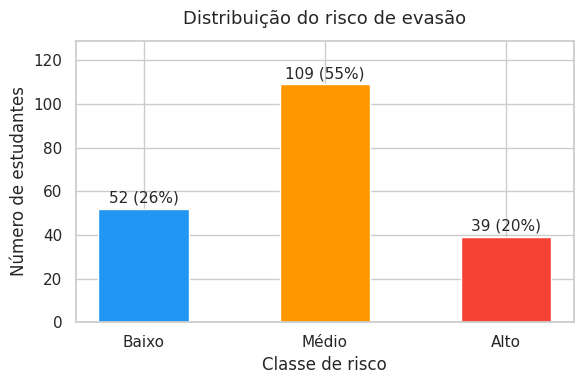

Gráfico salvo no Drive.


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

cores = ['#2196F3', '#FF9800', '#F44336']  # azul, laranja, vermelho
rotulos = ['Baixo', 'Médio', 'Alto']
contagem = df['risco'].value_counts().sort_index()  # conta alunos por classe

# Cria as barras
bars = ax.bar(rotulos, contagem.values, color=cores, width=0.5, edgecolor='white')

# Adiciona o valor e percentual em cima de cada barra
for bar, val in zip(bars, contagem.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posição x = centro da barra
        bar.get_height() + 1.5,              # posição y = topo + margem
        f'{val} ({val/n*100:.0f}%)',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Distribuição do risco de evasão', fontsize=13, pad=12)
ax.set_xlabel('Classe de risco')
ax.set_ylabel('Número de estudantes')
ax.set_ylim(0, contagem.max() + 20)

plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_classes.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo no Drive.')


## Célula 8 — Gráfico: boxplots por classe de risco

O boxplot mostra a distribuição de uma variável separada por classe.
É útil para verificar se as variáveis realmente separam bem as classes:
se os boxplots das três classes se sobrepõem muito, a variável tem pouco
poder preditivo.


/tmp/ipykernel_25168/75245755.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='risco_label', y='frequencia',
/tmp/ipykernel_25168/75245755.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='risco_label', y='media_notas',


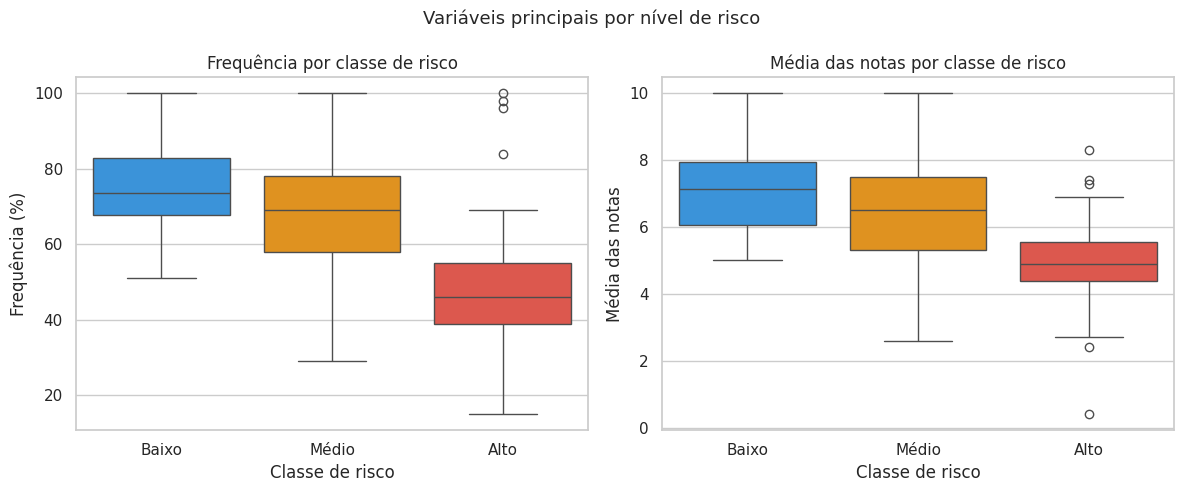

Gráfico salvo no Drive.


In [8]:
# Cria uma cópia com rótulos legíveis para o gráfico
df_plot = df.copy()
df_plot['risco_label'] = df_plot['risco'].map({0:'Baixo', 1:'Médio', 2:'Alto'})
ordem   = ['Baixo', 'Médio', 'Alto']
palette = {'Baixo':'#2196F3', 'Médio':'#FF9800', 'Alto':'#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot da frequência por classe
sns.boxplot(data=df_plot, x='risco_label', y='frequencia',
            order=ordem, palette=palette, ax=axes[0])
axes[0].set_title('Frequência por classe de risco')
axes[0].set_xlabel('Classe de risco')
axes[0].set_ylabel('Frequência (%)')

# Boxplot da média das notas por classe
sns.boxplot(data=df_plot, x='risco_label', y='media_notas',
            order=ordem, palette=palette, ax=axes[1])
axes[1].set_title('Média das notas por classe de risco')
axes[1].set_xlabel('Classe de risco')
axes[1].set_ylabel('Média das notas')

plt.suptitle('Variáveis principais por nível de risco', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_boxplots.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo no Drive.')


## Célula 9 — Gráfico: mapa de correlação

A correlação mede o quanto duas variáveis variam juntas.
Valores próximos de +1 indicam correlação positiva forte (quando uma sobe, a outra sobe).
Valores próximos de -1 indicam correlação negativa forte (quando uma sobe, a outra cai).
Próximos de 0 indicam pouca relação linear entre as variáveis.


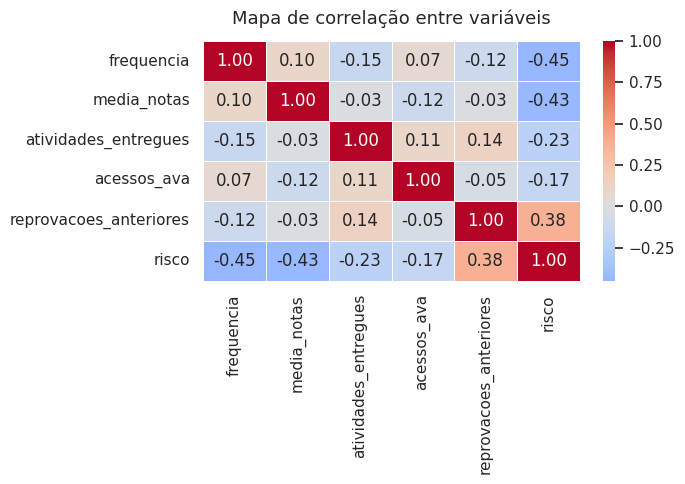

Correlação de cada variável com a coluna risco:
reprovacoes_anteriores    0.38
acessos_ava              -0.17
atividades_entregues     -0.23
media_notas              -0.43
frequencia               -0.45
Name: risco, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

# .corr() calcula a correlação de Pearson entre todos os pares de colunas
corr = df.corr().round(2)

# heatmap exibe a matriz de correlação com cores
# annot=True mostra os valores dentro das células
# cmap='coolwarm': azul = negativo, branco = zero, vermelho = positivo
# center=0: branco fica no zero
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)

ax.set_title('Mapa de correlação entre variáveis', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_correlacao.png', bbox_inches='tight')
plt.show()

print('Correlação de cada variável com a coluna risco:')
print(corr['risco'].drop('risco').sort_values(ascending=False))


---
# PARTE 2 — Machine Learning: Árvore de Decisão


## Célula 10 — Separar X e y

Em Machine Learning supervisionado sempre separamos:
- **X (features):** as variáveis que o modelo usa para aprender
- **y (target):** o que queremos que o modelo aprenda a prever

`df.drop('risco', axis=1)` remove a coluna `risco` de X.
`axis=1` significa que estamos removendo uma **coluna** (não uma linha).


In [10]:
# X: todas as colunas exceto 'risco' — são as entradas do modelo
X = df.drop('risco', axis=1)

# y: apenas a coluna 'risco' — é o que o modelo vai prever
y = df['risco']

print('Variáveis de entrada (X):', list(X.columns))
print(f'Shape de X: {X.shape}  →  {X.shape[0]} alunos, {X.shape[1]} variáveis')
print()
print('Variável alvo (y) — distribuição:')
print(y.value_counts().sort_index().rename({0:'Baixo',1:'Médio',2:'Alto'}))


Variáveis de entrada (X): ['frequencia', 'media_notas', 'atividades_entregues', 'acessos_ava', 'reprovacoes_anteriores']
Shape de X: (200, 5)  →  200 alunos, 5 variáveis

Variável alvo (y) — distribuição:
risco
Baixo     52
Médio    109
Alto      39
Name: count, dtype: int64


## Célula 11 — Dividir em treino e teste

Separamos os dados em dois grupos:
- **Treino (80%):** o modelo aprende com esses dados
- **Teste (20%):** usado apenas para avaliar o modelo após o treino

O modelo **nunca vê** os dados de teste durante o treino.
Isso simula dados novos e nos diz se o modelo generaliza bem.

`stratify=y` garante que a proporção de cada classe seja igual nos dois conjuntos.
`random_state=42` é uma semente: garante que a divisão seja a mesma toda vez que rodar.


In [11]:
# train_test_split divide X e y simultaneamente, mantendo a correspondência entre linhas
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% para teste, 80% para treino
    random_state=42,  # reprodutibilidade
    stratify=y        # mantém proporção das classes em treino e teste
)

print(f'Treino: {X_train.shape[0]} alunos | Teste: {X_test.shape[0]} alunos')
print()
print('Distribuição no treino:')
print(y_train.value_counts().sort_index().rename({0:'Baixo',1:'Médio',2:'Alto'}))
print()
print('Distribuição no teste:')
print(y_test.value_counts().sort_index().rename({0:'Baixo',1:'Médio',2:'Alto'}))


Treino: 160 alunos | Teste: 40 alunos

Distribuição no treino:
risco
Baixo    42
Médio    87
Alto     31
Name: count, dtype: int64

Distribuição no teste:
risco
Baixo    10
Médio    22
Alto      8
Name: count, dtype: int64


## Célula 12 — Treinar a Árvore de Decisão

A Árvore de Decisão aprende regras do tipo:
> *SE frequência < 50 E nota < 5 ENTÃO risco = alto*

Ela divide os dados em ramos escolhendo, a cada nó, a variável que melhor
separa as classes. Este algoritmo foi mencionado na disciplina pois suas regras
são práticas de interpretar e comparar com as regras fuzzy.

`max_depth=4` limita a profundidade a 4 níveis, evitando que a árvore
memorize os dados de treino (overfitting).

`.fit(X_train, y_train)` é o treino de fato: o modelo analisa os dados
e aprende quais divisões melhor separam as classes.


In [12]:
# Instancia o modelo com profundidade máxima de 4 níveis
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# Treina o modelo: ele analisa X_train e y_train e aprende as regras
clf.fit(X_train, y_train)

print('Modelo treinado com sucesso!')
print(f'Profundidade real da árvore: {clf.get_depth()} níveis')
print(f'Número de folhas (decisões finais): {clf.get_n_leaves()}')


Modelo treinado com sucesso!
Profundidade real da árvore: 4 níveis
Número de folhas (decisões finais): 14


## Célula 13 — Fazer previsões e avaliar o modelo

`.predict()` aplica o modelo treinado nos dados de teste e retorna
a classe prevista para cada aluno (0, 1 ou 2).

**Métricas de avaliação:**
- **Acurácia:** % de acertos no total
- **Precision:** dos que o modelo classificou como classe X, quantos realmente eram X?
- **Recall:** dos que realmente eram classe X, quantos o modelo identificou?
- **F1-score:** média harmônica entre precision e recall — métrica mais equilibrada


In [13]:
# .predict() classifica os 40 alunos do conjunto de teste
y_pred = clf.predict(X_test)

# Acurácia: proporção de previsões corretas sobre o total
acuracia = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acuracia:.2%}')  # .2% formata como porcentagem com 2 casas
print()

# Relatório completo com precision, recall e f1-score para cada classe
print('Relatório de classificação:')
print(classification_report(
    y_test, y_pred,
    target_names=['Baixo', 'Médio', 'Alto']  # nomes legíveis para as classes 0, 1, 2
))


Acurácia: 85.00%

Relatório de classificação:
              precision    recall  f1-score   support

       Baixo       1.00      0.50      0.67        10
       Médio       0.81      0.95      0.88        22
        Alto       0.89      1.00      0.94         8

    accuracy                           0.85        40
   macro avg       0.90      0.82      0.83        40
weighted avg       0.87      0.85      0.84        40



## Célula 14 — Gráfico: matriz de confusão

A diagonal principal (canto superior esquerdo ao inferior direito) mostra os acertos.
Os valores fora da diagonal são os erros e mostram **que tipo** de erro o modelo comete.
Por exemplo: um valor na linha 'Alto' e coluna 'Médio' significa que o modelo
classificou como médio um aluno que era realmente de risco alto.


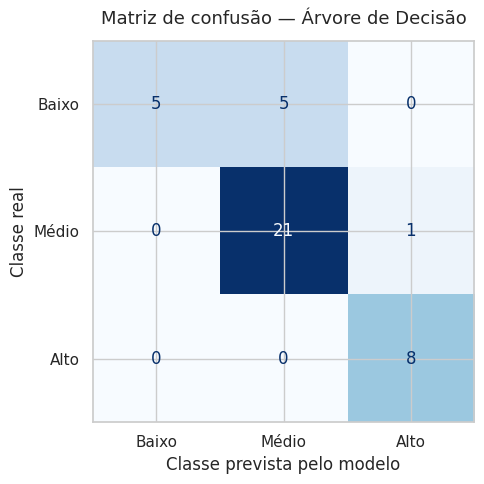

Gráfico salvo no Drive.


In [14]:
cm = confusion_matrix(y_test, y_pred)  # calcula a matriz de confusão

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Baixo', 'Médio', 'Alto']
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de confusão — Árvore de Decisão', fontsize=13, pad=12)
ax.set_xlabel('Classe prevista pelo modelo')
ax.set_ylabel('Classe real')
plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_matriz_confusao.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo no Drive.')


## Célula 15 — Gráfico: a árvore de decisão

Este gráfico mostra exatamente quais regras o modelo aprendeu.
Cada nó interno é uma pergunta (ex: `frequencia <= 49.5?`).
Cada folha é uma decisão final (ex: risco = alto).


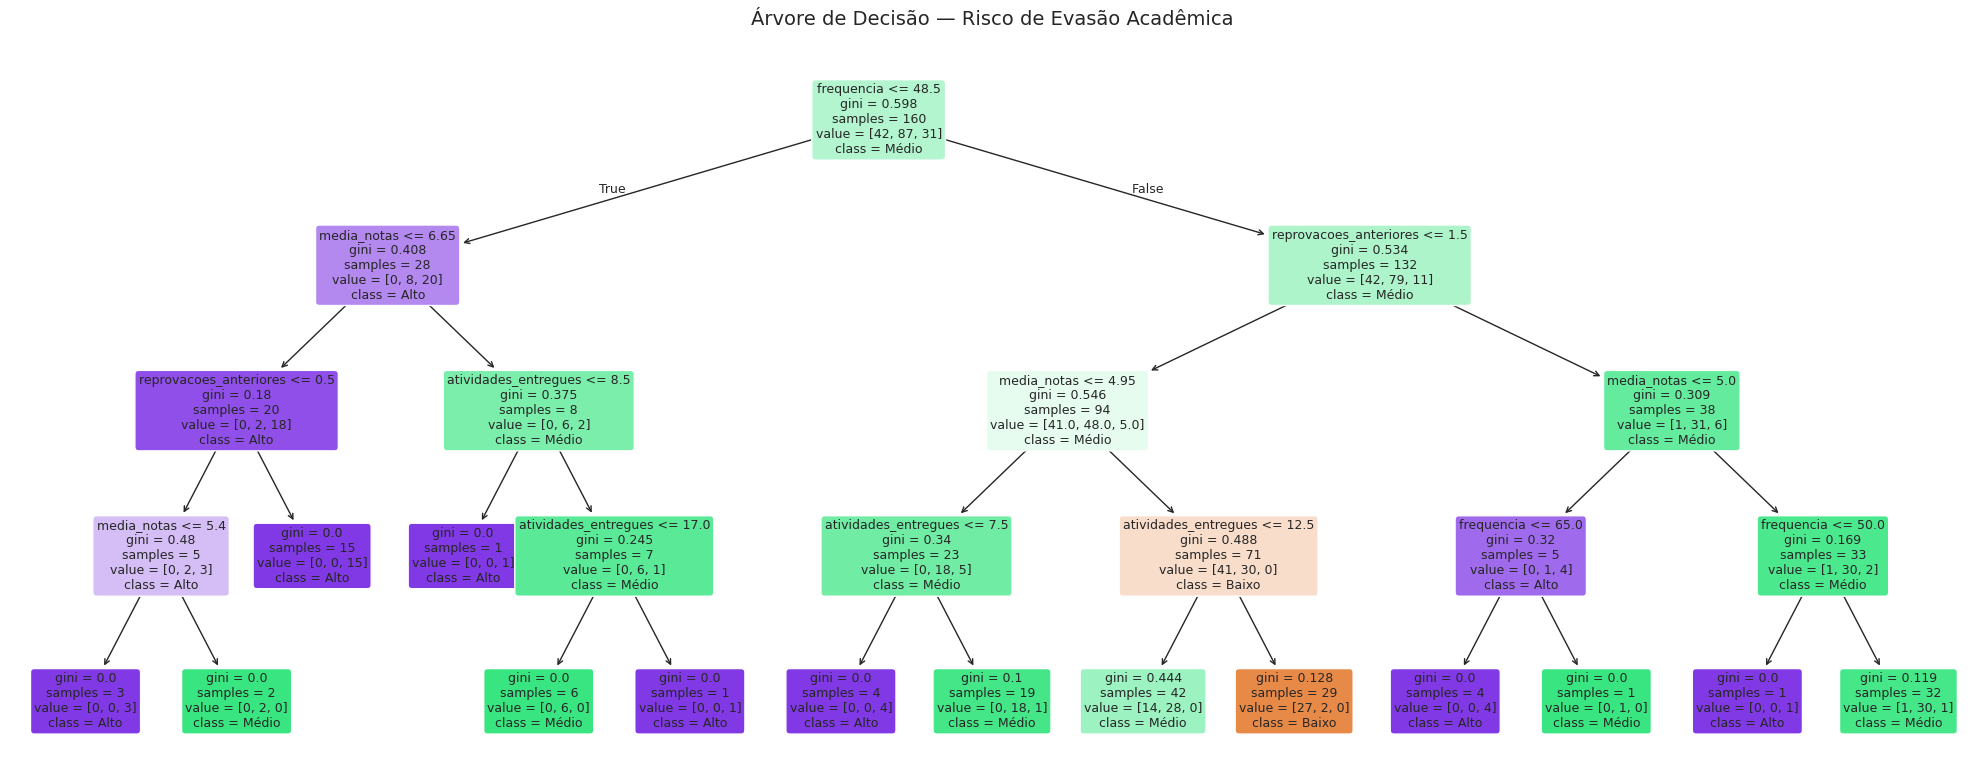

Gráfico salvo no Drive.


In [15]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf,
    feature_names=X.columns.tolist(),       # nomes das variáveis de entrada
    class_names=['Baixo', 'Médio', 'Alto'], # nomes das classes de saída
    filled=True,    # colorir os nós pela classe predominante
    rounded=True,   # bordas arredondadas nos nós
    fontsize=9,
    ax=ax
)
ax.set_title('Árvore de Decisão — Risco de Evasão Acadêmica', fontsize=14, pad=16)
plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_arvore.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo no Drive.')


In [17]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

## Célula 16 — Gráfico: importância das variáveis

`feature_importances_` é calculado automaticamente pela Árvore de Decisão.
Indica quais variáveis foram mais usadas nas divisões do modelo.
A variável mais importante é a que aparece nos nós mais altos da árvore,
pois separa melhor as classes desde o início.


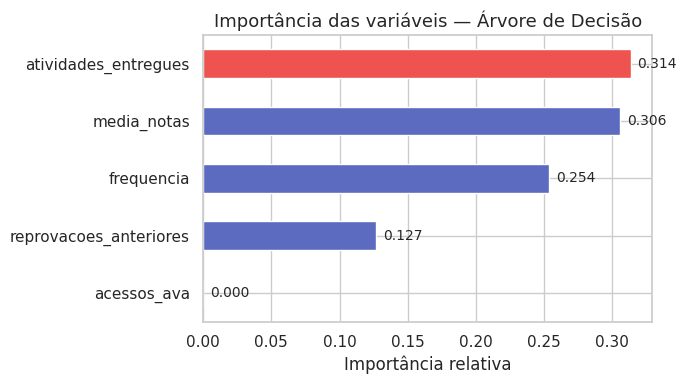

Variável mais importante: atividades_entregues


In [18]:
# feature_importances_ retorna um array com a importância relativa de cada variável
importancias = pd.Series(
    clf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)  # crescente para o barh ficar em ordem

fig, ax = plt.subplots(figsize=(7, 4))
cores = ['#EF5350' if v == importancias.max() else '#5C6BC0'
         for v in importancias.values]  # destaca a variável mais importante
importancias.plot(kind='barh', ax=ax, color=cores, edgecolor='white')

# Adiciona os valores ao lado de cada barra
for i, v in enumerate(importancias.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

ax.set_title('Importância das variáveis — Árvore de Decisão', fontsize=13)
ax.set_xlabel('Importância relativa')
plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_importancia.png', bbox_inches='tight')
plt.show()
print('Variável mais importante:', importancias.idxmax())


---
# PARTE 3 — Sistema de Inferência Fuzzy


## Célula 17 — Definir variáveis e funções de pertinência

A lógica fuzzy trabalha com **graus de pertinência**: um aluno com frequência
de 60% não é simplesmente 'média' ou 'baixa' — ele pertence parcialmente
a ambos os conjuntos.

**Variáveis de entrada:**
- `frequencia`: universo de 0 a 100 (porcentagem)
- `media_notas`: universo de 0 a 10

**Variável de saída:**
- `risco_evasao`: universo de 0 a 100 (score de risco)

**Funções de pertinência triangulares (`trimf`):**
Recebem 3 pontos [a, b, c]: grau 0 em `a`, grau 1 (pico) em `b`, grau 0 em `c`.

Exemplo: `frequencia['baixa'] = trimf([0, 0, 50])`
→ grau 1 em 0%, grau 0 em 50%, valores acima de 50% têm grau 0.


In [19]:
# --- VARIÁVEIS ANTECEDENTES (entradas) ---

# Frequência: valores inteiros de 0 a 100
frequencia_fz = ctrl.Antecedent(np.arange(0, 101, 1), 'frequencia')

# Média das notas: valores de 0 a 10 com passo 0.1
media_notas_fz = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'media_notas')

# --- VARIÁVEL CONSEQUENTE (saída) ---

# Risco de evasão: score de 0 (sem risco) a 100 (risco máximo)
risco_fz = ctrl.Consequent(np.arange(0, 101, 1), 'risco_evasao')

# --- FUNÇÕES DE PERTINÊNCIA: FREQUÊNCIA ---
# trimf(universo, [a, b, c]): triângulo com base em a e c, pico em b

# Baixa: frequência entre 0% e 50% (pico em 0%)
frequencia_fz['baixa'] = fuzz.trimf(frequencia_fz.universe, [0,  0,  50])
# Média: frequência entre 30% e 90% (pico em 60%)
frequencia_fz['media'] = fuzz.trimf(frequencia_fz.universe, [30, 60, 90])
# Alta: frequência entre 70% e 100% (pico em 100%)
frequencia_fz['alta']  = fuzz.trimf(frequencia_fz.universe, [70, 100, 100])

# --- FUNÇÕES DE PERTINÊNCIA: NOTA ---

# Baixa: nota entre 0 e 5 (pico em 0)
media_notas_fz['baixa'] = fuzz.trimf(media_notas_fz.universe, [0, 0, 5])
# Média: nota entre 3 e 8 (pico em 6)
media_notas_fz['media'] = fuzz.trimf(media_notas_fz.universe, [3, 6, 8])
# Alta: nota entre 6 e 10 (pico em 10)
media_notas_fz['alta']  = fuzz.trimf(media_notas_fz.universe, [6, 10, 10])

# --- FUNÇÕES DE PERTINÊNCIA: RISCO DE EVASÃO (saída) ---

# Baixo: score entre 0 e 40
risco_fz['baixo'] = fuzz.trimf(risco_fz.universe, [0,  0,  40])
# Médio: score entre 25 e 75 (pico em 50)
risco_fz['medio'] = fuzz.trimf(risco_fz.universe, [25, 50, 75])
# Alto: score entre 60 e 100
risco_fz['alto']  = fuzz.trimf(risco_fz.universe, [60, 100, 100])

print('Variáveis e funções de pertinência definidas com sucesso!')


Variáveis e funções de pertinência definidas com sucesso!


## Célula 18 — Visualizar as funções de pertinência

Estes gráficos mostram como cada variável fuzzy está definida.

O eixo X é o valor real (ex: frequência em %) e o eixo Y é o grau de pertinência (0 a 1).


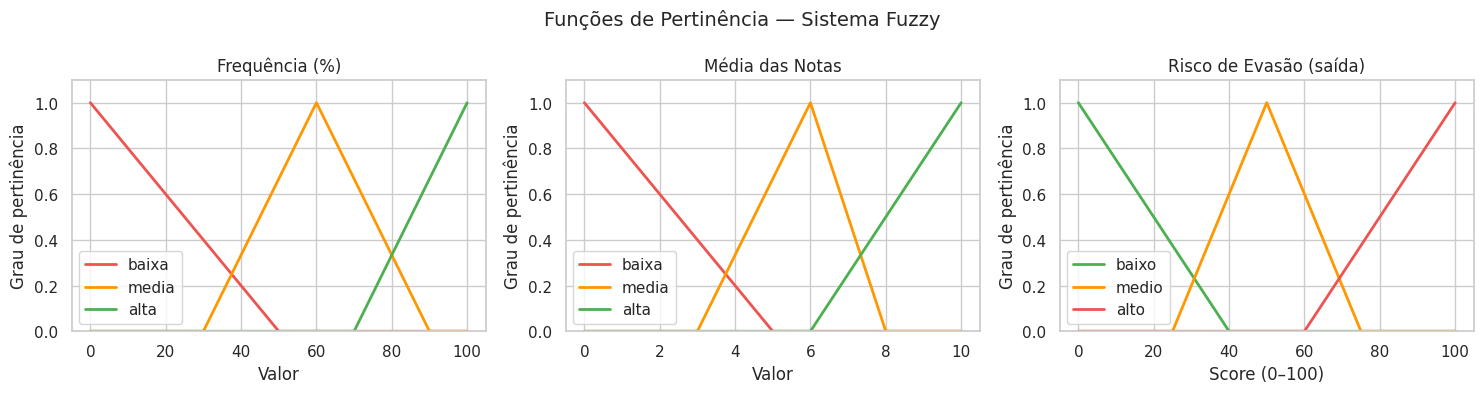

Gráfico salvo no Drive.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico das funções de pertinência da frequência
for termo, cor in zip(['baixa','media','alta'], ['#EF5350','#FF9800','#4CAF50']):
    axes[0].plot(
        frequencia_fz.universe,
        frequencia_fz[termo].mf,  # .mf = membership function (array de graus)
        label=termo, color=cor, linewidth=2
    )
axes[0].set_title('Frequência (%)', fontsize=12)
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Grau de pertinência')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Gráfico das funções de pertinência da média das notas
for termo, cor in zip(['baixa','media','alta'], ['#EF5350','#FF9800','#4CAF50']):
    axes[1].plot(
        media_notas_fz.universe,
        media_notas_fz[termo].mf,
        label=termo, color=cor, linewidth=2
    )
axes[1].set_title('Média das Notas', fontsize=12)
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Grau de pertinência')
axes[1].legend()
axes[1].set_ylim(0, 1.1)

# Gráfico das funções de pertinência do risco de evasão (saída)
for termo, cor in zip(['baixo','medio','alto'], ['#4CAF50','#FF9800','#EF5350']):
    axes[2].plot(
        risco_fz.universe,
        risco_fz[termo].mf,
        label=termo, color=cor, linewidth=2
    )
axes[2].set_title('Risco de Evasão (saída)', fontsize=12)
axes[2].set_xlabel('Score (0–100)')
axes[2].set_ylabel('Grau de pertinência')
axes[2].legend()
axes[2].set_ylim(0, 1.1)

plt.suptitle('Funções de Pertinência — Sistema Fuzzy', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_pertinencia.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo no Drive.')


## Célula 19 — Definir as regras fuzzy

As regras fuzzy seguem a estrutura **SE ... ENTÃO ...**
e representam o conhecimento especialista sobre o problema.

Usamos 9 regras cobrindo todas as combinações possíveis
(3 termos de frequência × 3 termos de nota = 9 regras).
O enunciado exige no mínimo 6 — nossas 9 regras superam esse requisito.

| Frequência | Nota | Risco |
|---|---|---|
| Baixa | Baixa | Alto |
| Baixa | Média | Alto |
| Baixa | Alta | Médio |
| Média | Baixa | Alto |
| Média | Média | Médio |
| Média | Alta | Baixo |
| Alta | Baixa | Médio |
| Alta | Média | Baixo |
| Alta | Alta | Baixo |


In [21]:
# Cada regra conecta condições (antecedentes) a uma conclusão (consequente)
# O operador & representa E (AND) lógico fuzzy

r1 = ctrl.Rule(frequencia_fz['baixa'] & media_notas_fz['baixa'], risco_fz['alto'])
r2 = ctrl.Rule(frequencia_fz['baixa'] & media_notas_fz['media'], risco_fz['alto'])
r3 = ctrl.Rule(frequencia_fz['baixa'] & media_notas_fz['alta'],  risco_fz['medio'])
r4 = ctrl.Rule(frequencia_fz['media'] & media_notas_fz['baixa'], risco_fz['alto'])
r5 = ctrl.Rule(frequencia_fz['media'] & media_notas_fz['media'], risco_fz['medio'])
r6 = ctrl.Rule(frequencia_fz['media'] & media_notas_fz['alta'],  risco_fz['baixo'])
r7 = ctrl.Rule(frequencia_fz['alta']  & media_notas_fz['baixa'], risco_fz['medio'])
r8 = ctrl.Rule(frequencia_fz['alta']  & media_notas_fz['media'], risco_fz['baixo'])
r9 = ctrl.Rule(frequencia_fz['alta']  & media_notas_fz['alta'],  risco_fz['baixo'])

# Monta o sistema de controle com todas as regras
sistema_fuzzy = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9])

# Cria a simulação — é o objeto que recebe entradas e calcula a saída
simulacao = ctrl.ControlSystemSimulation(sistema_fuzzy)

print('Sistema fuzzy com 9 regras criado com sucesso!')


Sistema fuzzy com 9 regras criado com sucesso!


## Célula 20 — Testar o sistema fuzzy com exemplos

Antes de aplicar em massa, testamos o sistema com 3 alunos fictícios
representando cada perfil de risco.


In [22]:
def calcular_fuzzy(freq, nota):
    """
    Calcula o score fuzzy de risco de evasão para um aluno.
    Parâmetros: freq (0-100), nota (0-10)
    Retorna: score numérico de risco (0-100)
    """
    # np.clip garante que os valores estejam dentro do universo definido
    simulacao.input['frequencia']  = float(np.clip(freq,  0, 100))
    simulacao.input['media_notas'] = float(np.clip(nota,  0, 10))
    simulacao.compute()  # executa fuzzificação + inferência + defuzzificação
    return simulacao.output['risco_evasao']


# Casos de teste representativos
casos = [
    ('Aluno A (risco baixo esperado)',  90, 8.5),
    ('Aluno B (risco médio esperado)',  60, 6.0),
    ('Aluno C (risco alto esperado)',   25, 2.5),
]

print('=== Casos de Teste — Sistema Fuzzy ===')
print(f'{"Aluno":<35} {"Freq":>6} {"Nota":>6} {"Score":>8} {"Classe":>8}')
print('-' * 65)

for nome, freq, nota in casos:
    score = calcular_fuzzy(freq, nota)
    # Classifica o score numérico em baixo/médio/alto
    if score < 40:   classe = 'Baixo'
    elif score < 70: classe = 'Médio'
    else:            classe = 'Alto'
    print(f'{nome:<35} {freq:>6}% {nota:>6.1f} {score:>8.1f} {classe:>8}')


=== Casos de Teste — Sistema Fuzzy ===
Aluno                                 Freq   Nota    Score   Classe
-----------------------------------------------------------------
Aluno A (risco baixo esperado)          90%    8.5     14.7    Baixo
Aluno B (risco médio esperado)          60%    6.0     50.0    Médio
Aluno C (risco alto esperado)           25%    2.5     84.4     Alto


---
# PARTE 4 — Comparação: ML vs Fuzzy (Abordagem A)


## Célula 21 — Aplicar fuzzy em todos os alunos do conjunto de teste

Aplicamos o sistema fuzzy nos mesmos 40 alunos que o modelo ML classificou.
Assim conseguimos comparar as duas abordagens para os mesmos dados.

A função `classif_fuzzy` converte o score numérico (0-100) em classe (0, 1, 2)
usando os mesmos limiares das funções de pertinência da saída:
- Score < 40 → baixo (0)
- Score 40–70 → médio (1)
- Score > 70 → alto (2)


In [23]:
def classif_fuzzy(score):
    """Converte o score fuzzy (0-100) em classe (0=baixo, 1=médio, 2=alto)"""
    if score < 40:   return 0
    elif score < 70: return 1
    return 2


# Aplica o sistema fuzzy para cada aluno do conjunto de teste
# .apply() percorre cada linha e chama calcular_fuzzy com frequência e nota daquele aluno
scores_fuzzy = X_test.apply(
    lambda row: calcular_fuzzy(row['frequencia'], row['media_notas']),
    axis=1
)

# Monta o DataFrame de comparação
comparacao = X_test[['frequencia', 'media_notas']].copy()
comparacao['risco_real']      = y_test.values   # gabarito
comparacao['risco_ml']        = y_pred           # previsão da Árvore de Decisão
comparacao['score_fuzzy']     = scores_fuzzy.values  # score numérico do fuzzy
comparacao['risco_fuzzy']     = scores_fuzzy.apply(classif_fuzzy).values

# Colunas auxiliares para análise
comparacao['ml_acertou']      = comparacao['risco_ml']    == comparacao['risco_real']
comparacao['fuzzy_acertou']   = comparacao['risco_fuzzy'] == comparacao['risco_real']
comparacao['ml_fuzzy_concordam'] = comparacao['risco_ml'] == comparacao['risco_fuzzy']

print(f'Total de alunos no teste: {len(comparacao)}')
print()
print('Primeiras 10 linhas da comparação:')
comparacao.head(10)


Total de alunos no teste: 40

Primeiras 10 linhas da comparação:


,frequencia,media_notas,risco_real,risco_ml,score_fuzzy,risco_fuzzy,ml_acertou,fuzzy_acertou,ml_fuzzy_concordam
107,71,5.1,0,1,48.592144,1,False,False,True
142,35,6.6,1,2,57.825629,1,False,True,False
66,66,9.1,0,0,13.884354,0,True,True,True
5,63,4.5,1,1,54.531494,1,True,True,True
95,38,5.0,2,2,63.217656,1,True,False,False
125,100,4.0,2,2,31.684906,0,True,False,False
1,65,7.2,1,1,37.594484,0,True,False,False
151,74,8.9,1,1,15.313131,0,True,False,False
133,77,5.0,1,1,40.017688,1,True,True,True
109,66,5.8,1,1,50.000000,1,True,True,True


## Célula 22 — Métricas de comparação

Aqui calculamos os números que vão para o relatório na seção
'Integração ou Comparação'.


In [24]:
ac_ml    = comparacao['ml_acertou'].mean()
ac_fuzzy = comparacao['fuzzy_acertou'].mean()
concord  = comparacao['ml_fuzzy_concordam'].mean()
diverg   = (~comparacao['ml_fuzzy_concordam']).sum()

print('=== COMPARAÇÃO: ML vs FUZZY ===')
print(f'Acurácia do ML (Árvore de Decisão) : {ac_ml:.2%}')
print(f'Acurácia do Fuzzy                  : {ac_fuzzy:.2%}')
print(f'Concordância entre ML e Fuzzy      : {concord:.2%}')
print(f'Casos de divergência               : {diverg} alunos')
print()

# Exibe os casos onde ML e Fuzzy divergiram
print('Casos onde ML e Fuzzy divergiram:')
divergentes = comparacao[~comparacao['ml_fuzzy_concordam']][[
    'frequencia','media_notas','risco_real','risco_ml','score_fuzzy','risco_fuzzy'
]]
divergentes = divergentes.replace({0:'Baixo', 1:'Médio', 2:'Alto'})
print(divergentes.to_string())


=== COMPARAÇÃO: ML vs FUZZY ===
Acurácia do ML (Árvore de Decisão) : 85.00%
Acurácia do Fuzzy                  : 47.50%
Concordância entre ML e Fuzzy      : 42.50%
Casos de divergência               : 23 alunos

Casos onde ML e Fuzzy divergiram:
     frequencia  media_notas risco_real risco_ml  score_fuzzy risco_fuzzy
142          35          6.6      Médio     Alto    57.825629       Médio
95           38          5.0       Alto     Alto    63.217656       Médio
125         100          4.0       Alto     Alto    31.684906       Baixo
1            65          7.2      Médio    Médio    37.594484       Baixo
151          74          8.9      Médio    Médio    15.313131       Baixo
78           69          6.3      Baixo    Baixo    47.081587       Médio
96           73          7.8      Médio    Médio    24.080599       Baixo
148          78          4.9      Médio    Médio    39.573237       Baixo
20           97         10.0      Baixo    Médio    13.454545       Baixo
156         10

## Célula 23 — Gráfico: comparação visual ML vs Fuzzy

Este gráfico coloca lado a lado as classificações do ML e do Fuzzy
para cada aluno do conjunto de teste, ordenados por frequência.


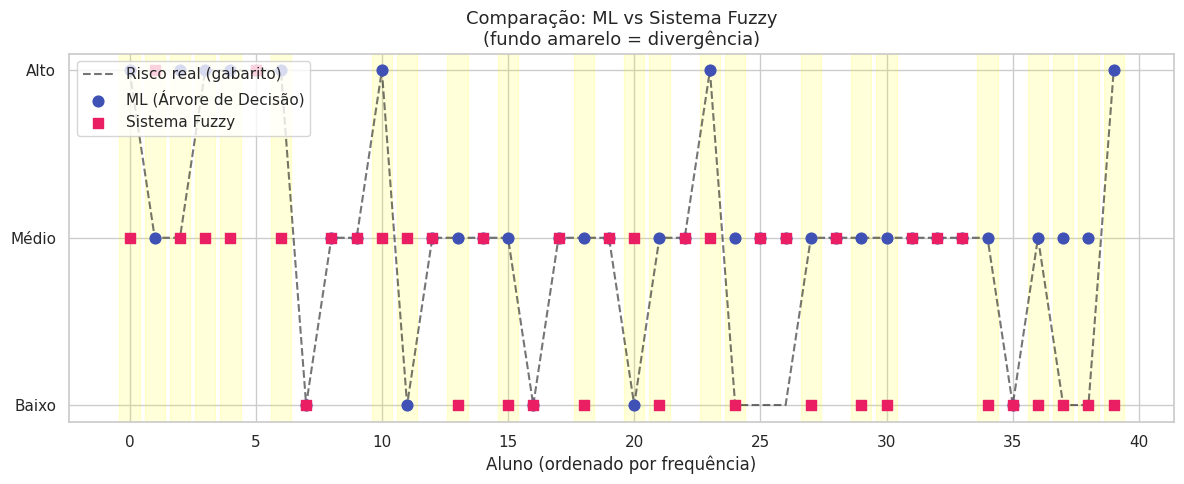

Gráfico salvo no Drive.


In [25]:
# Ordena por frequência para facilitar a visualização
comp_ord = comparacao.sort_values('frequencia').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(comp_ord))

# Linha da classificação real (gabarito)
ax.plot(x, comp_ord['risco_real'],  'k--', linewidth=1.5,
        label='Risco real (gabarito)', alpha=0.6)

# Pontos do ML
ax.scatter(x, comp_ord['risco_ml'],    color='#3F51B5', marker='o',
           s=60, label='ML (Árvore de Decisão)', zorder=5)

# Pontos do Fuzzy
ax.scatter(x, comp_ord['risco_fuzzy'], color='#E91E63', marker='s',
           s=60, label='Sistema Fuzzy', zorder=5)

# Destacar divergências com fundo amarelo
for i, row in comp_ord.iterrows():
    if row['risco_ml'] != row['risco_fuzzy']:
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.15, color='yellow')

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Baixo', 'Médio', 'Alto'])
ax.set_xlabel('Aluno (ordenado por frequência)')
ax.set_title('Comparação: ML vs Sistema Fuzzy\n(fundo amarelo = divergência)', fontsize=13)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_comparacao_ml_fuzzy.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo no Drive.')


## Célula 24 — Gráfico: superfície de decisão fuzzy

Este gráfico mostra como o sistema fuzzy se comporta para todas as
combinações possíveis de frequência e nota.

A representação também mostra que a lógica fuzzy
produz transições suaves entre os níveis de risco, ao contrário
da Árvore de Decisão que faz cortes abruptos.

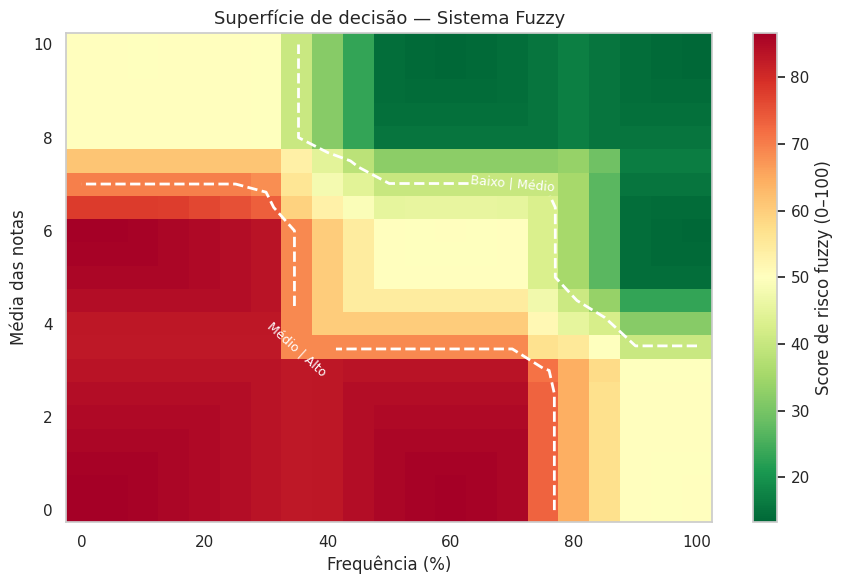

Gráfico salvo no Drive.


In [26]:
# Cria uma grade com todas as combinações de frequência (0-100) e nota (0-10)
freqs = np.arange(0, 101, 5)   # 0, 5, 10, ..., 100
notas = np.arange(0, 10.5, 0.5)  # 0, 0.5, 1.0, ..., 10

# Inicializa a matriz de resultados
superficie = np.zeros((len(freqs), len(notas)))

# Calcula o score fuzzy para cada combinação
for i, f in enumerate(freqs):
    for j, n in enumerate(notas):
        superficie[i, j] = calcular_fuzzy(f, n)

fig, ax = plt.subplots(figsize=(9, 6))

# pcolormesh cria um mapa de calor 2D
# superficie.T transpõe a matriz para orientação correta (nota no eixo X, freq no Y)
mesh = ax.pcolormesh(
    freqs, notas, superficie.T,
    cmap='RdYlGn_r',  # vermelho=alto risco, verde=baixo risco
    shading='auto'
)

# Adicionar linhas de contorno nos limiares de classificação
cs = ax.contour(
    freqs, notas, superficie.T,
    levels=[40, 70],  # limiares: <40=baixo, 40-70=médio, >70=alto
    colors='white', linewidths=2, linestyles='--'
)
ax.clabel(cs, fmt={40: 'Baixo | Médio', 70: 'Médio | Alto'}, fontsize=9)

plt.colorbar(mesh, ax=ax, label='Score de risco fuzzy (0–100)')
ax.set_xlabel('Frequência (%)')
ax.set_ylabel('Média das notas')
ax.set_title('Superfície de decisão — Sistema Fuzzy', fontsize=13)

plt.tight_layout()
plt.savefig(f'{PASTA}/grafico_superficie_fuzzy.png', bbox_inches='tight')
plt.show()
print('Gráfico salvo no Drive.')


## Célula 25 — Resumo final e arquivos gerados


In [27]:
print('=' * 50)
print('RESUMO FINAL DO TRABALHO')
print('=' * 50)
print()
print('PARTE 1 — Base de Dados')
print(f'  Registros gerados : {len(df)}')
print(f'  Variáveis         : {len(df.columns)}')
print(f'  Valores nulos     : {df.isnull().sum().sum()}')
print()
print('PARTE 2 — Machine Learning')
print(f'  Algoritmo         : Árvore de Decisão (max_depth=4)')
print(f'  Treino / Teste    : {X_train.shape[0]} / {X_test.shape[0]} alunos')
print(f'  Acurácia          : {ac_ml:.2%}')
print()
print('PARTE 3 — Sistema Fuzzy')
print(f'  Variáveis entrada : frequencia, media_notas')
print(f'  Variável saída    : risco_evasao (0-100)')
print(f'  Regras fuzzy      : 9 regras (SE...ENTÃO)')
print(f'  Acurácia          : {ac_fuzzy:.2%}')
print()
print('PARTE 4 — Comparação (Abordagem A)')
print(f'  Concordância ML x Fuzzy : {concord:.2%}')
print(f'  Casos de divergência    : {diverg} alunos')
print()
print('Arquivos salvos no Drive:')
arquivos = [
    'evasao.csv',
    'grafico_classes.png',
    'grafico_boxplots.png',
    'grafico_correlacao.png',
    'grafico_matriz_confusao.png',
    'grafico_arvore.png',
    'grafico_importancia.png',
    'grafico_pertinencia.png',
    'grafico_comparacao_ml_fuzzy.png',
    'grafico_superficie_fuzzy.png',
]
for a in arquivos:
    print(f'  {a}')


RESUMO FINAL DO TRABALHO

PARTE 1 — Base de Dados
  Registros gerados : 200
  Variáveis         : 6
  Valores nulos     : 0

PARTE 2 — Machine Learning
  Algoritmo         : Árvore de Decisão (max_depth=4)
  Treino / Teste    : 160 / 40 alunos
  Acurácia          : 85.00%

PARTE 3 — Sistema Fuzzy
  Variáveis entrada : frequencia, media_notas
  Variável saída    : risco_evasao (0-100)
  Regras fuzzy      : 9 regras (SE...ENTÃO)
  Acurácia          : 47.50%

PARTE 4 — Comparação (Abordagem A)
  Concordância ML x Fuzzy : 42.50%
  Casos de divergência    : 23 alunos

Arquivos salvos no Drive:
  evasao.csv
  grafico_classes.png
  grafico_boxplots.png
  grafico_correlacao.png
  grafico_matriz_confusao.png
  grafico_arvore.png
  grafico_importancia.png
  grafico_pertinencia.png
  grafico_comparacao_ml_fuzzy.png
  grafico_superficie_fuzzy.png
